# Forecast Error Analysis — GB Wind Generation

Analyses BMRS WINDFOR forecast accuracy against actual wind generation (FUELHH)
from January 2025 onwards.

**Methodology**: For every 30-minute actual, we join it with all forecasts targeting
the same half-hour. Horizon = `(start_time − publish_time) / 3600 seconds`.
This gives a full picture of how accuracy degrades with horizon without needing
49 separate API calls.

In [1]:
import sqlite3
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings('ignore')
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('ggplot')

pd.set_option('display.float_format', '{:.1f}'.format)
print('Setup complete')

Setup complete


## 1. Load Data

Reads directly from the SQLite database the backend populates.
Make sure you've fetched some data first via the API.

In [2]:
db_path = None
for candidate in [
    '../backend/data/wind_monitor.db',
    '../../backend/data/wind_monitor.db',
    os.path.join(os.path.dirname(os.getcwd()), 'backend', 'data', 'wind_monitor.db'),
]:
    if os.path.exists(candidate):
        db_path = candidate
        break

if db_path is None:
    raise FileNotFoundError(
        'Database not found. Start the backend and trigger a data load:\n'
        '  curl "http://localhost:3000/api/combined-data?start=2025-01-01&end=TODAY&horizon=4"'
    )

print(f'DB path: {os.path.abspath(db_path)}')

conn = sqlite3.connect(db_path)
actuals_raw = pd.read_sql_query(
    'SELECT start_time, generation FROM actuals ORDER BY start_time', conn
)
forecasts_raw = pd.read_sql_query(
    'SELECT start_time, publish_time, generation FROM forecasts ORDER BY start_time, publish_time',
    conn,
)
conn.close()

print(f'Actuals   : {len(actuals_raw):,} records')
print(f'Forecasts : {len(forecasts_raw):,} records')
print(f'Range     : {actuals_raw.start_time.min()} -> {actuals_raw.start_time.max()}')

DB path: /Users/likhith_n/Downloads/Backup/REint AI/wind-forecast-monitor/backend/data/wind_monitor.db
Actuals   : 1,464 records
Forecasts : 12,256 records
Range     : 2026-02-15T00:00:00Z -> 2026-03-17T11:30:00Z


## 2. Parse, Clean, and Merge

In [3]:
actuals = actuals_raw.copy()
actuals['start_time'] = pd.to_datetime(actuals['start_time'], utc=True)
actuals.rename(columns={'generation': 'actual_mw'}, inplace=True)
actuals = actuals[(actuals['actual_mw'] >= 0) & (actuals['actual_mw'] < 25000)]

forecasts = forecasts_raw.copy()
forecasts['start_time']   = pd.to_datetime(forecasts['start_time'],   utc=True)
forecasts['publish_time'] = pd.to_datetime(forecasts['publish_time'], utc=True)
forecasts.rename(columns={'generation': 'forecast_mw'}, inplace=True)

# Each actual gets paired with every forecast targeting the same half-hour
df = actuals.merge(forecasts, on='start_time', how='inner')

# How far in advance was this forecast made?
df['horizon_h'] = (df['start_time'] - df['publish_time']).dt.total_seconds() / 3600

# Keep valid horizons 0-48h (negatives = retro-corrections, skip those)
df = df[(df['horizon_h'] >= 0) & (df['horizon_h'] <= 48.5)]

# Error = actual - forecast  (positive = actual > forecast = under-forecast)
df['error_mw']     = df['actual_mw'] - df['forecast_mw']
df['abs_error_mw'] = df['error_mw'].abs()
# MAPE only reliable when actual > 0 (avoid division by near-zero)
df['mape_pct'] = np.where(
    df['actual_mw'] > 100,
    df['abs_error_mw'] / df['actual_mw'] * 100,
    np.nan,
)

print(f'Merged pairs   : {len(df):,}')
print(f'Horizon range  : {df["horizon_h"].min():.1f}h -> {df["horizon_h"].max():.1f}h')
if len(df) == 0:
    print('\nWARNING: No data — fetch data via the API first.')

Merged pairs   : 11,644
Horizon range  : 0.0h -> 47.5h


## 3. Overall Error Metrics

In [4]:
if len(df) > 0:
    mae    = df['abs_error_mw'].mean()
    rmse   = np.sqrt((df['error_mw'] ** 2).mean())
    mape   = df['mape_pct'].mean()
    bias   = df['error_mw'].mean()
    median = df['abs_error_mw'].median()
    p95    = np.percentile(df['abs_error_mw'].dropna(), 95)
    p99    = np.percentile(df['abs_error_mw'].dropna(), 99)

    print('Overall Error Metrics (all horizons combined)')
    print('=' * 48)
    print(f'  MAE              : {mae:>9,.0f} MW')
    print(f'  RMSE             : {rmse:>9,.0f} MW')
    print(f'  Median Abs Error : {median:>9,.0f} MW')
    print(f'  MAPE             : {mape:>9.1f} %  (actuals > 100 MW only)')
    print(f'  Bias             : {bias:>+9,.0f} MW  (+ = actual > forecast)')
    print(f'  P95 Abs Error    : {p95:>9,.0f} MW')
    print(f'  P99 Abs Error    : {p99:>9,.0f} MW')
    print(f'  N pairs          : {len(df):>9,}')

Overall Error Metrics (all horizons combined)
  MAE              :     2,033 MW
  RMSE             :     2,409 MW
  Median Abs Error :     1,925 MW
  MAPE             :      21.5 %  (actuals > 100 MW only)
  Bias             :    -1,790 MW  (+ = actual > forecast)
  P95 Abs Error    :     4,135 MW
  P99 Abs Error    :     5,459 MW
  N pairs          :    11,644


## 4. Error by Forecast Horizon

MAE and RMSE should increase with horizon — a 1h-ahead forecast should be
much more accurate than a 48h-ahead forecast. Bias may also shift direction.

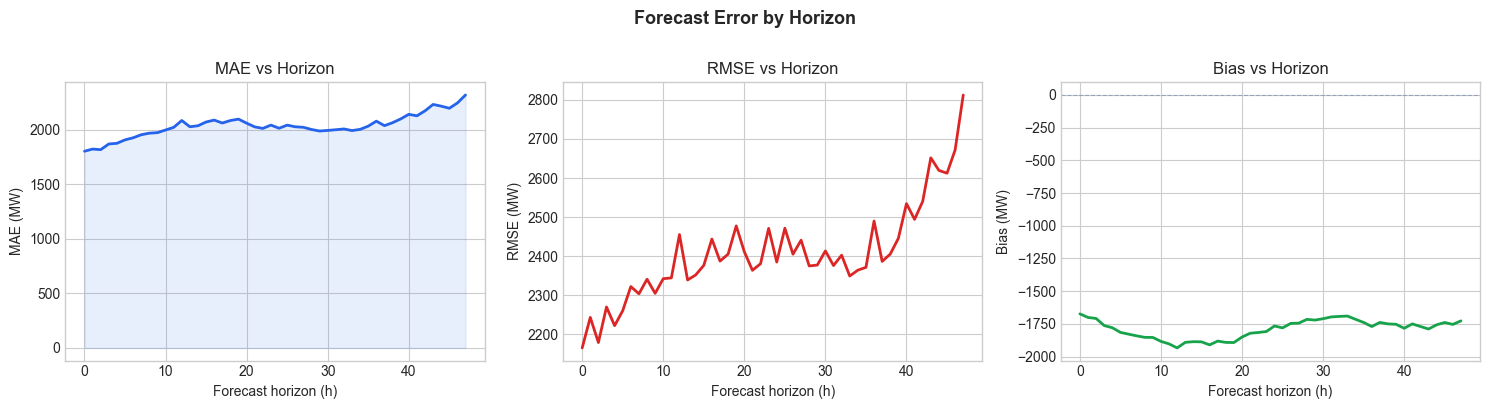

MAE at 0h baseline : 1,802 MW
MAE doubles (>3,604 MW) at : N/Ah

 horizon_bucket    mae   rmse    bias   n
              0 1801.8 2165.1 -1673.6 244
              1 1821.5 2243.3 -1701.1 245
              2 1816.2 2179.0 -1708.9 244
              3 1868.2 2270.0 -1763.4 244
              4 1874.3 2222.1 -1779.7 243
              5 1905.8 2260.5 -1815.5 244
              6 1924.9 2322.2 -1828.8 244
              7 1952.7 2303.7 -1841.9 243
              8 1967.1 2341.0 -1853.3 244
              9 1971.8 2304.8 -1854.1 243
             10 1996.2 2342.3 -1884.2 243
             11 2020.2 2344.3 -1903.5 243
             12 2083.2 2455.3 -1934.3 244
             13 2025.8 2339.1 -1891.5 243
             14 2035.1 2351.9 -1886.5 244
             15 2069.5 2376.5 -1887.7 244
             16 2087.1 2443.8 -1910.9 245
             17 2060.2 2387.3 -1881.9 244
             18 2083.0 2405.2 -1892.2 244
             19 2095.8 2477.5 -1892.9 245
             20 2058.7 2411.2 -1850.9 244
           

In [5]:
if len(df) > 0:
    df['horizon_bucket'] = df['horizon_h'].apply(int)

    h_stats = (
        df.groupby('horizon_bucket')
        .agg(
            mae  = ('abs_error_mw', 'mean'),
            rmse = ('error_mw', lambda x: np.sqrt((x ** 2).mean())),
            bias = ('error_mw', 'mean'),
            n    = ('error_mw', 'count'),
        )
        .reset_index()
    )

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(h_stats['horizon_bucket'], h_stats['mae'], color='#2563eb', lw=2)
    axes[0].fill_between(h_stats['horizon_bucket'], h_stats['mae'], alpha=0.1, color='#2563eb')
    axes[0].set(title='MAE vs Horizon', xlabel='Forecast horizon (h)', ylabel='MAE (MW)')

    axes[1].plot(h_stats['horizon_bucket'], h_stats['rmse'], color='#dc2626', lw=2)
    axes[1].set(title='RMSE vs Horizon', xlabel='Forecast horizon (h)', ylabel='RMSE (MW)')

    axes[2].axhline(0, color='#94a3b8', ls='--', lw=0.8)
    axes[2].plot(h_stats['horizon_bucket'], h_stats['bias'], color='#16a34a', lw=2)
    axes[2].set(title='Bias vs Horizon', xlabel='Forecast horizon (h)', ylabel='Bias (MW)')

    plt.suptitle('Forecast Error by Horizon', y=1.01, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../error_by_horizon.png', dpi=120, bbox_inches='tight')
    plt.show()

    # Show where MAE doubles relative to 0h baseline
    base = h_stats.loc[h_stats['horizon_bucket'] == 0, 'mae']
    if len(base) > 0:
        threshold = base.values[0] * 2
        cross = h_stats.loc[h_stats['mae'] >= threshold, 'horizon_bucket']
        crossover = cross.min() if len(cross) > 0 else 'N/A'
        print(f'MAE at 0h baseline : {base.values[0]:,.0f} MW')
        print(f'MAE doubles (>{threshold:,.0f} MW) at : {crossover}h')

    print()
    print(h_stats.to_string(index=False))

## 5. Temporal Error Patterns

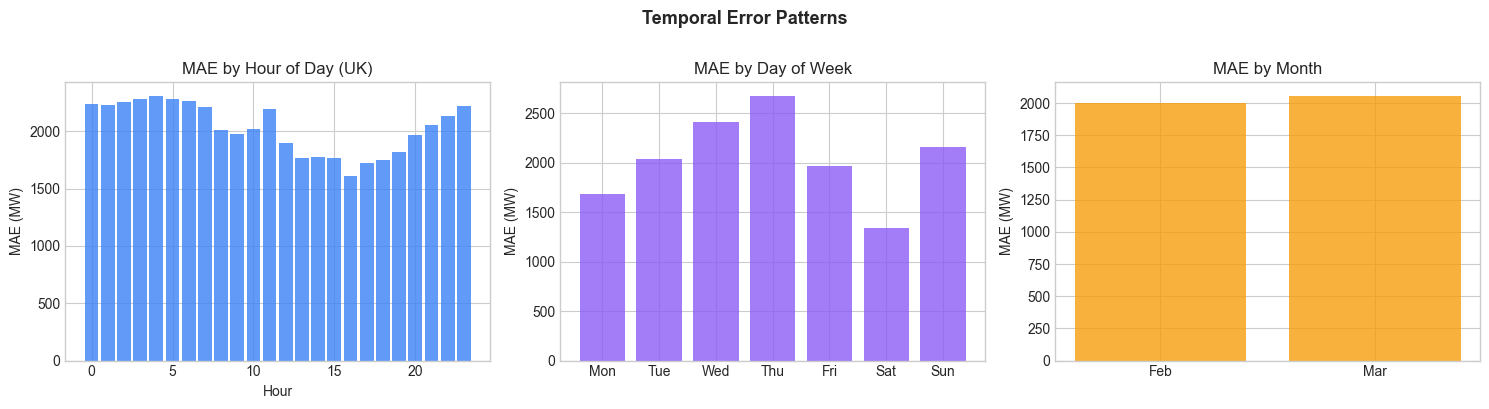

In [6]:
if len(df) > 0:
    df['uk_time'] = df['start_time'].dt.tz_convert('Europe/London')
    df['hour']  = df['uk_time'].dt.hour
    df['dow']   = df['uk_time'].dt.dayofweek
    df['month'] = df['uk_time'].dt.month

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    hour_mae = df.groupby('hour')['abs_error_mw'].mean()
    axes[0].bar(hour_mae.index, hour_mae.values, color='#3b82f6', alpha=0.8, width=0.85)
    axes[0].set(title='MAE by Hour of Day (UK)', xlabel='Hour', ylabel='MAE (MW)')

    day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
    dow_mae = df.groupby('dow')['abs_error_mw'].mean().reindex(range(7))
    axes[1].bar(day_labels, dow_mae.values, color='#8b5cf6', alpha=0.8)
    axes[1].set(title='MAE by Day of Week', ylabel='MAE (MW)')

    mth_map = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
    mth_mae = df.groupby('month')['abs_error_mw'].mean()
    axes[2].bar([mth_map[m] for m in mth_mae.index], mth_mae.values, color='#f59e0b', alpha=0.8)
    axes[2].set(title='MAE by Month', ylabel='MAE (MW)')

    plt.suptitle('Temporal Error Patterns', y=1.01, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../error_temporal_patterns.png', dpi=120, bbox_inches='tight')
    plt.show()

## 6. Error Distribution

Is the error Gaussian? Is there a systematic directional bias?

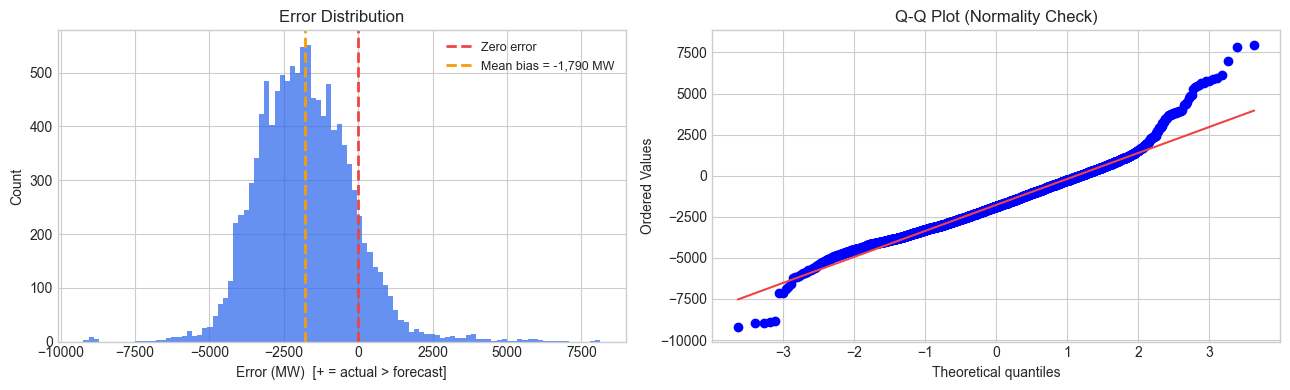

Skewness        : +0.529   (0 = symmetric)
Excess kurtosis : +2.373   (0 = normal; >0 = heavier tails)

Systematic bias detected: model over-forecasts (actual < forecast)
Average bias magnitude: 1,790 MW


In [7]:
if len(df) > 0:
    errors = df['error_mw'].dropna()

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].hist(errors, bins=100, color='#2563eb', alpha=0.7, edgecolor='none')
    axes[0].axvline(0,    color='#ef4444', ls='--', lw=2, label='Zero error')
    axes[0].axvline(bias, color='#f59e0b', ls='--', lw=2,
                    label=f'Mean bias = {bias:+,.0f} MW')
    axes[0].set(title='Error Distribution',
                xlabel='Error (MW)  [+ = actual > forecast]', ylabel='Count')
    axes[0].legend(fontsize=9)

    # Q-Q plot (sample to keep it fast)
    sample = errors.sample(min(5000, len(errors)), random_state=42)
    stats.probplot(sample, dist='norm', plot=axes[1])
    axes[1].set_title('Q-Q Plot (Normality Check)')
    axes[1].get_lines()[1].set_color('#ef4444')

    plt.tight_layout()
    plt.savefig('../error_distribution.png', dpi=120, bbox_inches='tight')
    plt.show()

    skew = errors.skew()
    kurt = errors.kurtosis()
    print(f'Skewness        : {skew:+.3f}   (0 = symmetric)')
    print(f'Excess kurtosis : {kurt:+.3f}   (0 = normal; >0 = heavier tails)')
    print()
    if abs(bias) > 150:
        direction = 'over-forecasts (actual < forecast)' if bias < 0 else 'under-forecasts (actual > forecast)'
        print(f'Systematic bias detected: model {direction}')
        print(f'Average bias magnitude: {abs(bias):,.0f} MW')
    else:
        print(f'Small bias ({bias:+.0f} MW) — no strong systematic over/under-forecast detected')

## 7. Key Findings

*(Update this section after running with real data)*

| Metric | Value |
|---|---|
| MAE (all horizons) | __ MW |
| RMSE | __ MW |
| MAPE | __ % |
| Bias | +/- __ MW |
| Horizon where MAE doubles | ~__h |
| P99 abs error | __ MW |

### Observations
- **Horizon degradation**: error increases __ up to ~__h, then flattens
- **Diurnal pattern**: errors peak around __ (linked to wind ramp events)
- **Bias direction**: model tends to __ which may indicate ...
- **Tail risk**: P99 of __ MW drives the reserve sizing requirement

### Limitations
- Only ~2-3 months of data — seasonal patterns not fully captured
- Errors may shift as BMRS updates its forecast model
- FUELHH aggregates onshore + offshore wind (spatial diversity not visible)